# Esame Laboratorio di Programmazione II - 13/01/2026


Scrivete chiaramente sul notebook il vostro nome e matricola e sul nome con cui salvate il file la vostra matricola.

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domanda e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza ettichette sugli assi o illleggibili sarà valutato meno bene di uno con ettichette chiare.

Commentate il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [1]:
#Potete importare direttamente qui le librerie che userete

## Esercizio 1
Un sensore ha registrato le seguenti temperature giornaliere (in °C) durante 12 giorni consecutivi:  
`18, 21, 19, 23, 25, 22, 20, 24, 26, 27, 21, 19`

1. Calcola la temperatura media del periodo.  
2. A causa di una ricalibrazione, tutte le temperature superiori a 22 °C devono essere aumentate di 1 °C. Aggiorna il vettore.  
3. Quanti giorni hanno registrato una temperatura pari o superiore a 25 °C dopo la ricalibrazione?


#### LEGGENDA

- **np.array([...], dtype=float)** -> Crea array di float

- **.mean()** -> Calcola la media

- **array > valore** -> Confronto vettoriale

- **array[mask] += 1** -> Aggiunge 1 agli elementi selezionati

- **np.sum(array >= valore)** -> Conta gli elementi maggiori o uguali a un valore

In [8]:
import numpy as np

# 1. Creo array e calcolo temperature
temp = np.array([18, 21, 19, 23, 25, 22, 20, 24, 26, 27, 21, 19], dtype=float)
print("PUNTO 1: ")
print("- Temperature originali:", temp.tolist())
media = temp.mean()
print(f"- Temperatura media: {media:.2f} °C")


# 2. Aumento di 1° C le temperature > 22
temp[temp > 22] += 1
print("\nPUNTO 2: ")
print("- Temperature dopo ricalibrazione:", temp.tolist())


# 3. Quanti giorni con temperatura >= 25
giorni_caldi = np.sum(temp >= 25)
print("\nPUNTO 3: ")
print(f"- Numero di giorni con temperatura >= 25 °C: {giorni_caldi}")

PUNTO 1: 
- Temperature originali: [18.0, 21.0, 19.0, 23.0, 25.0, 22.0, 20.0, 24.0, 26.0, 27.0, 21.0, 19.0]
- Temperatura media: 22.08 °C

PUNTO 2: 
- Temperature dopo ricalibrazione: [18.0, 21.0, 19.0, 24.0, 26.0, 22.0, 20.0, 25.0, 27.0, 28.0, 21.0, 19.0]

PUNTO 3: 
- Numero di giorni con temperatura >= 25 °C: 4


## Esercizio 2

Un’urna contiene **3 palline rosse** e **2 palline blu**.  
Dopo ogni estrazione la pallina viene **rimessa nell’urna**.

1. Scrivi una funzione che simula **N estrazioni** e restituisce un array NumPy (`1 = rossa`, `0 = blu`).

2. Per valori di N pari a 50, 100, 150, …, 500:
   - ripeti la simulazione **100 volte**
   - calcola la **frequenza relativa media** delle palline rosse.

3. Rappresenta graficamente l’**andamento della frequenza relativa media delle palline rosse** in funzione del numero di estrazioni.


#### LEGGENDA

- **np.random.choice([1,0], size=N, p=[0.6,0.4])** -> Simula N estrazioni con reinserimento (1=rossa, 0=blu)

- **np.mean(array)** -> Proporzione di 1 (rosse) in una singola simulazione

- **ciclo for per le 100 ripetizioni** -> Calcola la media delle medie

- **plt.plot(N_list, medie, marker='o')** -> Grafico dell’andamento

- **plt.grid(True)** -> Griglia nel grafico

PUNTO 1 – Esempio di 10 estrazioni: [1, 0, 0, 1, 1, 0, 1, 0, 0, 1]

PUNTO2: 
- N =  50: frequenza media di rosse = 0.6072
- N = 100: frequenza media di rosse = 0.6106
- N = 150: frequenza media di rosse = 0.6014
- N = 200: frequenza media di rosse = 0.6026
- N = 250: frequenza media di rosse = 0.5982
- N = 300: frequenza media di rosse = 0.5975
- N = 350: frequenza media di rosse = 0.5953
- N = 400: frequenza media di rosse = 0.5981
- N = 450: frequenza media di rosse = 0.5963
- N = 500: frequenza media di rosse = 0.6041

PUNTO 3 - Grafico dell'andamento delle frequenze


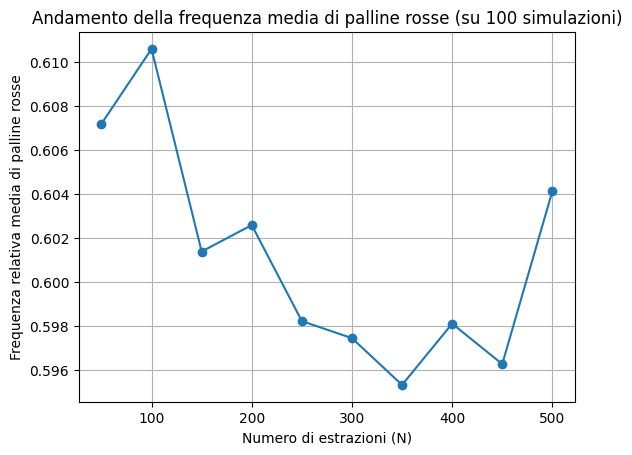

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Funzione che simula N estrazioni
def estrai(N):
    return np.random.choice([1, 0], size=N, p=[3/5, 2/5])

np.random.seed(0)
print("PUNTO 1 – Esempio di 10 estrazioni:", estrai(10).tolist())


# 2. Per N=50,100,...,500, ripeto 100 volte e calcolo frequenza media
N_values = list(range(50, 501, 50))            # [50,100,...,500]
medie_frequenze = []

print ("\nPUNTO2: ")
for N in N_values:
    frequenze = []
    for _ in range(100):
        risultati = estrai(N)
        freq = risultati.mean()               # Proporzione di rosse
        frequenze.append(freq)
    media_freq = np.mean(frequenze)
    medie_frequenze.append(media_freq)
    print(f"- N = {N:3d}: frequenza media di rosse = {media_freq:.4f}")


# PUNTO 3: Grafico
print ("\nPUNTO 3 - Grafico dell'andamento delle frequenze")
plt.plot(N_values, medie_frequenze, marker='o')
plt.xlabel('Numero di estrazioni (N)')
plt.ylabel('Frequenza relativa media di palline rosse')
plt.title('Andamento della frequenza media di palline rosse (su 100 simulazioni)')
plt.grid(True)
plt.show()

## Esercizio 3

1. Genera una matrice NumPy di dimensioni **6 x 8**, con valori estratti da una distribuzione normale con **media = 2** e **deviazione standard = 3**.

2. Per ogni riga, individua il valore **più vicino a zero** (cioè con valore assoluto minimo). Crea un array con questi **6 valori** (uno per riga).

3. Calcola quante righe hanno come valore più vicino a zero un numero **negativo**.


#### LEGGENDA

- **np.random.normal(media, std, size)** -> Genera matrice con distribuzione normale

- **np.abs(riga)** -> Valore assoluto elemento per elemento

- **np.argmin(array)** -> Indice del valore minimo

- **riga[indice]** -> Valore in quella posizione

- **valore < 0** -> Maschera booleana per valori negativi

- **np.sum(mask)** -> Conta i True

In [22]:
import numpy as np

# 1. Genero la matrice
np.random.seed(0)
matrice = np.random.normal(2, 3, (6, 8))
print("PUNTO 1 – Matrice generata (prime 2 righe):")
print(np.round(matrice[:2], 4))


# 2. Per ogni riga, valore più vicino a zero
vicini_zero = []
for i in range(6):
    riga = matrice[i]
    distanze = np.abs(riga - 0)      # Distanza assoluta dallo zero
    indice_min = np.argmin(distanze)
    valore = riga[indice_min]
    vicini_zero.append(float(valore))


print("\nPUNTO 2 – Valore più vicino a zero per ogni riga:")
print([round(v, 4) for v in vicini_zero])


# 3. Conto quante righe hanno valore negativo
negativi = np.sum(np.array(vicini_zero) < 0)
print(f"\nPUNTO 3 – Numero di righe con valore più vicino a zero negativo: {negativi}")

PUNTO 1 – Matrice generata (prime 2 righe):
[[ 7.2922  3.2005  4.9362  8.7227  7.6027 -0.9318  4.8503  1.5459]
 [ 1.6903  3.2318  2.4321  6.3628  4.2831  2.365   3.3316  3.001 ]]

PUNTO 2 – Valore più vicino a zero per ogni riga:
[-0.9318, 1.6903, -0.2265, 1.4384, -0.6634, 0.471]

PUNTO 3 – Numero di righe con valore più vicino a zero negativo: 3


In [27]:
# ===========================================================================
# (Setup) creazione dataset `students.csv` (da eseguire una sola volta)
# ===========================================================================

def make_students_csv(filename="students.csv", n=60, seed=42):
    """
    Dataset più "significativo":
    - exam_score cresce (non linearmente) con study_hours e attendance
    - presenza di cluster (studenti regolari / altalenanti / molto bravi)
    - qualche outlier (molte ore ma voto medio, poche ore ma voto alto)
    - qualche valore mancante
    """
    rng = np.random.default_rng(seed)

    student_id = np.arange(1, n + 1)

    group = rng.choice([0, 1, 2], size=n, p=[0.45, 0.40, 0.15])

    study_hours = np.empty(n, dtype=int)
    attendance = np.empty(n, dtype=float)

    idx0 = group == 0
    study_hours[idx0] = rng.integers(12, 28, size=idx0.sum())
    attendance[idx0] = rng.uniform(0.78, 1.00, size=idx0.sum())

    idx1 = group == 1
    study_hours[idx1] = rng.integers(5, 22, size=idx1.sum())
    attendance[idx1] = rng.uniform(0.60, 0.95, size=idx1.sum())

    idx2 = group == 2
    study_hours[idx2] = rng.integers(22, 45, size=idx2.sum())
    attendance[idx2] = rng.uniform(0.85, 1.00, size=idx2.sum())

    attendance = np.round(attendance, 2)

    noise = rng.normal(0, 6, size=n)
    nonlinear_bonus = 8 / (1 + np.exp(-(study_hours - 25) / 4))  # "curva a S"
    exam_score = 35 + 1.4 * study_hours + 22 * (attendance - 0.6) + nonlinear_bonus + noise
    exam_score = np.clip(exam_score, 35, 100)
    exam_score = np.round(exam_score).astype(float)

    for i in rng.choice(np.where(study_hours > 30)[0], size=min(2, np.sum(study_hours > 30)), replace=False):
        exam_score[i] = max(40, exam_score[i] - rng.integers(12, 20))

    for i in rng.choice(np.where(study_hours < 12)[0], size=min(2, np.sum(study_hours < 12)), replace=False):
        exam_score[i] = min(100, exam_score[i] + rng.integers(12, 20))

    p_pass = 1 / (1 + np.exp(-(exam_score - 62) / 6))
    passed = (rng.uniform(0, 1, size=n) < p_pass).astype(int)

    df = pd.DataFrame({
        "student_id": student_id,
        "exam_score": exam_score,
        "study_hours": study_hours,
        "attendance": attendance,
        "passed": passed
    })

    miss_att = rng.choice(df.index, size=max(1, n // 30), replace=False)
    miss_score = rng.choice(df.index.difference(miss_att), size=max(1, n // 30), replace=False)
    df.loc[miss_att, "attendance"] = np.nan
    df.loc[miss_score, "exam_score"] = np.nan

    df.to_csv(filename, index=False)
    return df

df = make_students_csv("students.csv", n=60, seed=0)
print(df.head())


   student_id  exam_score  study_hours  attendance  passed
0           1        68.0           11         NaN       1
1           2        70.0           21        0.99       0
2           3        74.0           18        0.89       1
3           4        82.0           27        0.87       1
4           5        67.0           18        0.85       1


## Esercizio 4

Utilizza il dataset `students.csv`, che contiene le seguenti colonne:  
`student_id`, `exam_score`, `study_hours`, `attendance`, `passed`  
(dove `passed` vale 1 se lo studente ha superato l’esame, 0 altrimenti).

1. Verifica la presenza di **valori mancanti per colonna** ed elimina le righe che ne contengono.

2. Crea una nuova colonna `performance_index` definita come:

   $$
   \texttt{performance\_index} = \texttt{exam\_score} \times \texttt{attendance}
   $$

3. Filtra gli studenti che hanno:
   - `study_hours` > 20  
   - `attendance` > 0.8  

4. Crea un **grafico a barre** con i **10 studenti con performance_index più alto**
   (usa `student_id` come etichetta).

5. Crea uno **scatter plot** con:
   - asse x = `study_hours`
   - asse y = `exam_score`
   - colore dei punti = `performance_index`

#### LEGGENDA

- **pd.read_csv('students.csv')** -> Carica il dataset

- **df.isnull().sum()** -> Conta i valori mancanti per colonna

- **df.dropna()** -> Elimina righe con NaN

- **df['performance_index'] = df['exam_score'] * df['attendance']** -> Nuova colonna

- **df[(df['study_hours'] > 20) & (df['attendance'] > 0.8)]** -> Filtro con due condizioni

- **df.nlargest(10, 'performance_index')** -> Prende i 10 con performance_index più alto

- **plt.bar(df['student_id'], df['performance_index'])** -> Grafico a barre

- **plt.scatter(x, y, c=colore)** -> Scatter plot con colore

- **plt.grid ()** -> Aggiuge la griglia al grafico

- **plt.colorbar(label='...')** -> Barra dei colori

PUNTO 1: 
- Dimensioni originali: (60, 5)
- Valori mancanti per colonna:
 student_id     0
exam_score     2
study_hours    0
attendance     2
passed         0
dtype: int64
- Dimensioni dopo dropna: (56, 5)

PUNTO 2 - Prime 3 righe con performance_index:
   student_id  exam_score  attendance  performance_index
1           2        70.0        0.99              69.30
2           3        74.0        0.89              65.86
3           4        82.0        0.87              71.34

PUNTO 3 - Numero di studenti che soddisfano i criteri: 23
   student_id  study_hours  attendance
1           2           21        0.99
3           4           27        0.87
5           6           32        0.93

PUNTO 4 - Grafico a barre dei top 10 performance_index


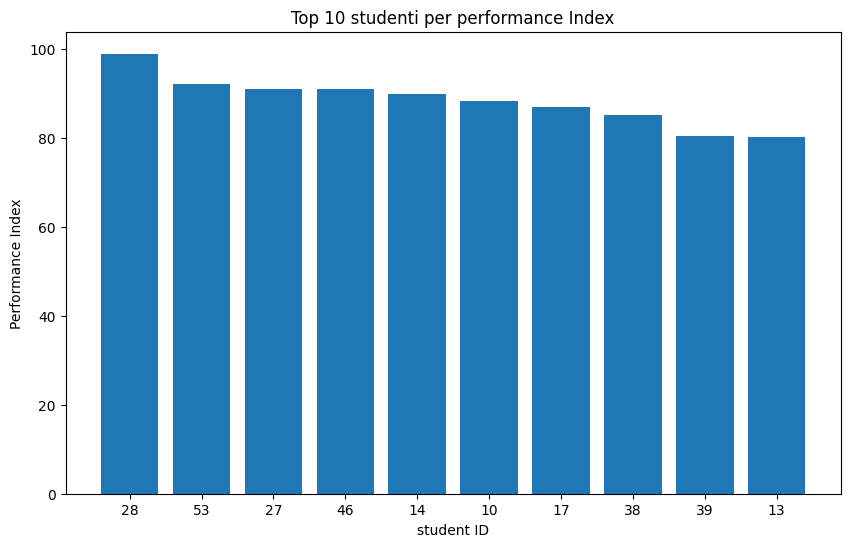


PUNTO 5 - Scatter plot study_hours vs exam_score (colore = performance_index)


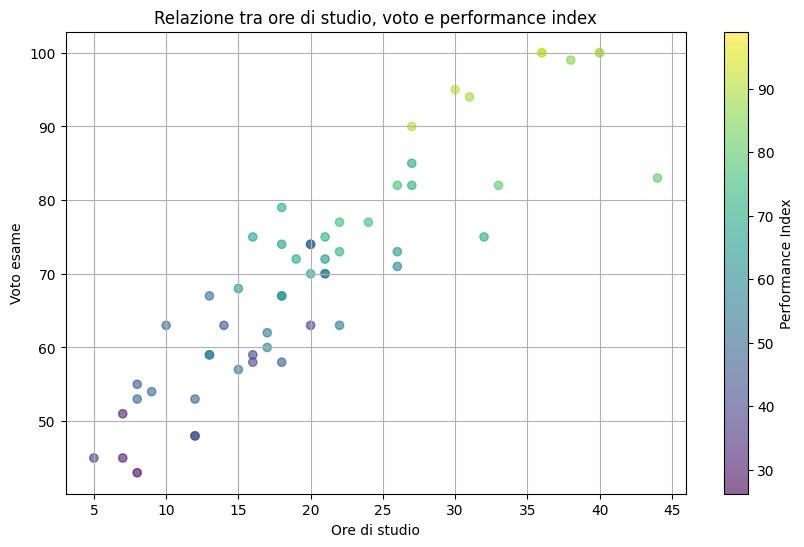

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carico, controllo NaN, ed elimino righe con NaN
df = pd.read_csv('students.csv')
print("PUNTO 1: ")
print("- Dimensioni originali:", df.shape)
print("- Valori mancanti per colonna:\n", df.isnull().sum())

df = df.dropna()
print("- Dimensioni dopo dropna:", df.shape)


# 2. Creo colonna performance_index
df['performance_index'] = df['exam_score'] * df['attendance']
print ("\nPUNTO 2 - Prime 3 righe con performance_index:")
print (df[['student_id', 'exam_score', 'attendance', 'performance_index']].head(3))


# 3. Filtro study_hours > 20 e attendance > 0.8
filtro = df[(df['study_hours'] > 20) & (df['attendance'] > 0.8)]
print (f"\nPUNTO 3 - Numero di studenti che soddisfano i criteri: {len(filtro)}")
if len (filtro) > 0:
    print(filtro[['student_id', 'study_hours', 'attendance']]. head(3))


# 4. Grafico a barre
top_10 = df.nlargest (10, 'performance_index')
print (f"\nPUNTO 4 - Grafico a barre dei top 10 performance_index")
plt.figure (figsize = (10, 6))
plt.bar (top_10['student_id'].astype(str), top_10['performance_index'])
plt.xlabel ('student ID')
plt.ylabel ('Performance Index')
plt.title ('Top 10 studenti per performance Index')
plt.show ()


# 5. Scatter plot
print (f"\nPUNTO 5 - Scatter plot study_hours vs exam_score (colore = performance_index)")
plt.figure (figsize = (10, 6))
sc = plt.scatter(df['study_hours'], df['exam_score'], c = df['performance_index'], alpha = 0.6)
plt.colorbar (sc, label = 'Performance Index')
plt.xlabel ('Ore di studio')
plt.ylabel ('Voto esame')
plt.title ('Relazione tra ore di studio, voto e performance index')
plt.grid ()
plt.show ()



## Esercizio 5

Utilizza lo stesso dataset `students.csv`.

1. Determina **numero di righe e colonne** del dataset ed elimina la colonna `passed`.

2. Trova il **valore di `exam_score` più frequente**.

3. Calcola la **media del punteggio d’esame (`exam_score`) per fasce di ore di studio**:
   - `0–10`
   - `11–20`
   - `21–30`
   - `>30`

4. Crea un **boxplot** dei valori di `exam_score` raggruppati per fascia di ore di studio.

5. Crea un **violin plot** della distribuzione di `attendance` per ciascuna fascia di ore di studio.


#### LEGGENDA 

- **df.shape** -> Numero di righe e colonne

- **df.drop(columns=['col'])** -> Elimina una colonna

- **df['col'].value_counts().idxmax()** -> Valore più frequente

- **pd.cut(df['col'], bins, labels)** -> Crea fasce (binning)

- **df.groupby('fascia')['val'].mean()** -> Media per gruppo

- **sns.boxplot(x='fascia', y='val', data=df)** -> Boxplot

- **sns.violinplot(x='fascia', y='val', data=df)** -> Violin plot


PUNTO 1: 
- Righe: 56, Colonne: 4
- Colonne dopo l'eliminazione di passed: 4

PUNTO 2:
- Valore di exam_score più prequente: 63.0

PUNTO 3 - Media exam_score per fasca ore: 
hour_group
0-10     51.125000
11-20    63.916667
21-30    77.000000
> 30     92.555556
Name: exam_score, dtype: float64

PUNTO 4 - Boxplot exam_score per fascia ore:


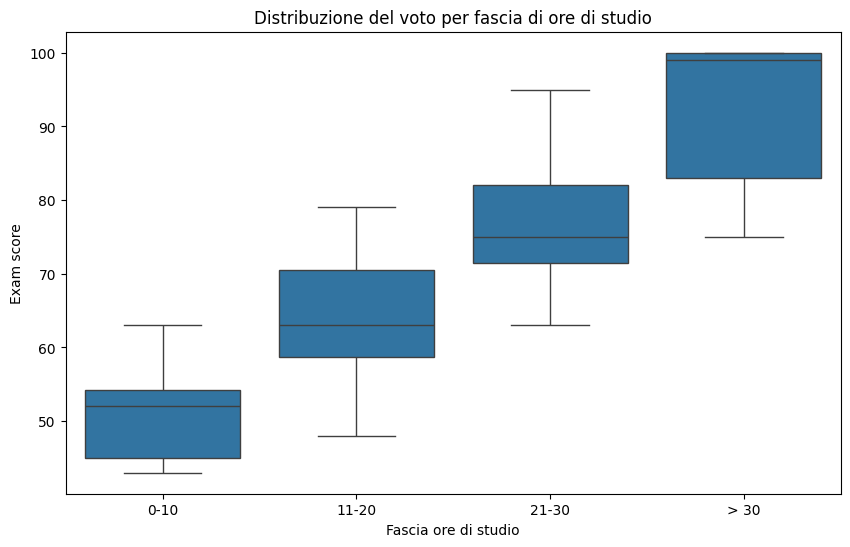


PUNTO 5 - Violin plot ddi attendance per fascia ore:


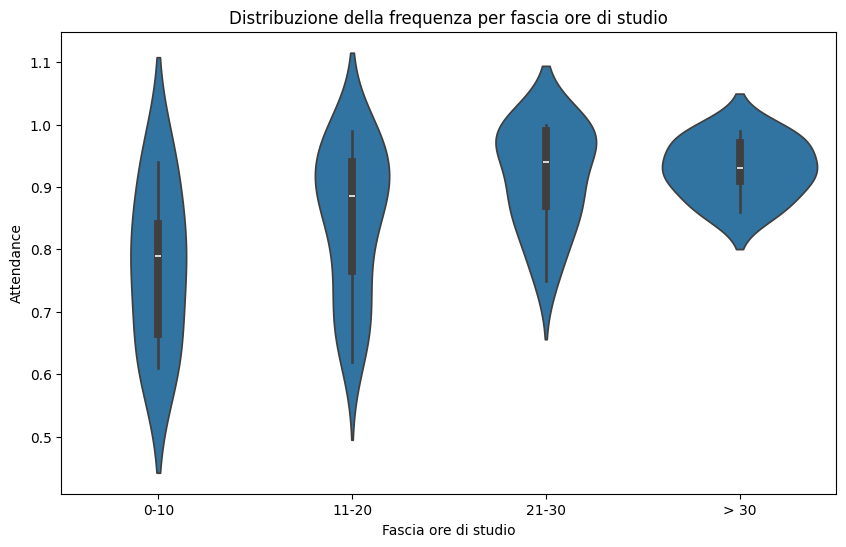

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carico il dataset e pulizia dei NaN
df = pd.read_csv ('students.csv')       # Carico il database
df = df.dropna()                        # Pulisco i NaN


# 1. Dimensioni ed eliminazione colonna passed
df = df.drop(columns = ['passed'])
print ("\nPUNTO 1: ")
print (f"- Righe: {df.shape[0]}, Colonne: {df.shape[1]}")
print ("- Colonne dopo l'eliminazione di passed:", df.shape[1])


# 2. Valore più frequente di exam_score
moda_voto = df['exam_score'].value_counts().idxmax()
print ("\nPUNTO 2:")
print (f"- Valore di exam_score più prequente: {moda_voto}")


# 3. Media exam_score per fascia di ore di studio
bins = [0, 10, 20, 30, 100]
labels = ['0-10', '11-20', '21-30', '> 30']
df['hour_group'] = pd.cut(df['study_hours'], bins = bins, labels = labels)

media_fasce = df.groupby ('hour_group')['exam_score'].mean()
print ("\nPUNTO 3 - Media exam_score per fasca ore: ")
print (media_fasce)


# 4. Boxplot 

print ("\nPUNTO 4 - Boxplot exam_score per fascia ore:")
plt.figure (figsize = (10, 6))
sns.boxplot (x = 'hour_group', y = 'exam_score', data = df)
plt.xlabel ('Fascia ore di studio')
plt.ylabel ('Exam score')
plt.title('Distribuzione del voto per fascia di ore di studio')
plt.show ()


# 5. Violin plot 

print ("\nPUNTO 5 - Violin plot ddi attendance per fascia ore:")
plt.figure (figsize = (10, 6))
sns.violinplot (x = 'hour_group', y = 'attendance', data = df)
plt.xlabel ('Fascia ore di studio')
plt.ylabel ('Attendance')
plt.title ('Distribuzione della frequenza per fascia ore di studio')
plt.show ()

## Esercizio 6

Genera due array:

`x = np.linspace(0, 5, 80)`  
`y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)`

1. Usa `scipy.optimize.curve_fit` per stimare i parametri `a` e `b` della retta del tipo:

    $$
   y = a \cdot x + b
    $$

2. Plotta i punti originali e la retta ottenuta.

3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:  

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$


#### LEGGENDA

- **np.linspace(0, 5, 80)** -> Crea 80 punti equidistanti tra 0 e 5

- **np.random.normal(0, 0.5, 80)** -> Genera 80 errori casuali con media 0 e std 0.5

- **curve_fit(modello, x, y)** -> Restituisce parametri ottimali (popt) e matrice di covarianza (pcov)

- **modello_lineare(x, a, b)** -> Restituisce a*x + b

- **mean_absolute_error(y, y_pred)** -> MAE

- **np.sqrt(mean_squared_error(y, y_pred))** -> RMSE

- **plt.scatter(x, y)** -> Grafico a punti

- **plt.plot(x, y_pred, 'r-')** -> Retta stimata

PUNTO 1: 
Parametri stimati: a = 2.3830, b = 1.4772

PUNTO 2 - Grafico


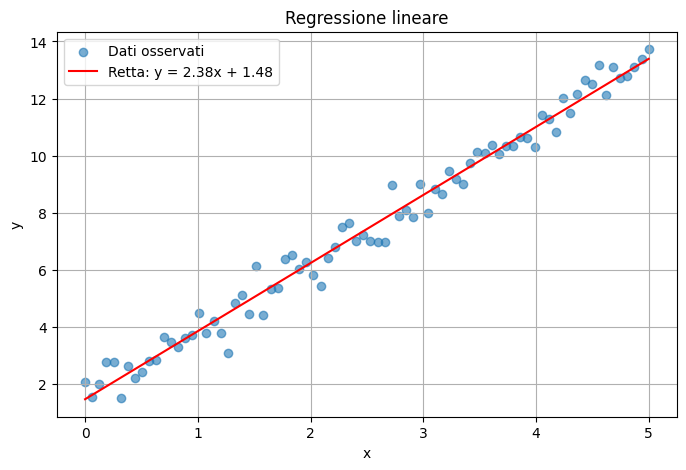


PUNTO 3: 
- MAE = 0.3685
- RMSE = 0.4731


In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Creo i dati e stimo i parametri
np.random.seed(0)
x = np.linspace(0, 5, 80)
y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)    

def modello_lineare(x, a, b):
    return a * x + b

popt, __ = curve_fit(modello_lineare, x, y)
a, b = popt
print("PUNTO 1: ")
print(f"Parametri stimati: a = {a:.4f}, b = {b:.4f}")


# 2. Grafico punti e retta
print("\nPUNTO 2 - Grafico")
y_pred = modello_lineare(x, a, b)

plt.figure(figsize=(8,5))
plt.scatter(x, y, label='Dati osservati', alpha=0.6)
plt.plot(x, y_pred, 'r-', label=f'Retta: y = {a:.2f}x + {b:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressione lineare')
plt.legend()
plt.grid()
plt.show()


# 3.  MAE e RMSE
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("\nPUNTO 3: ")
print(f"- MAE = {mae:.4f}")
print(f"- RMSE = {rmse:.4f}")
